In [1]:
#01_feature selection filter methods
  #correlation
  #chi square
  #Mutual Information


In [8]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
data = load_breast_cancer()
x = pd.DataFrame( data.data , columns = data.feature_names)
y = pd.Series (data.target)
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


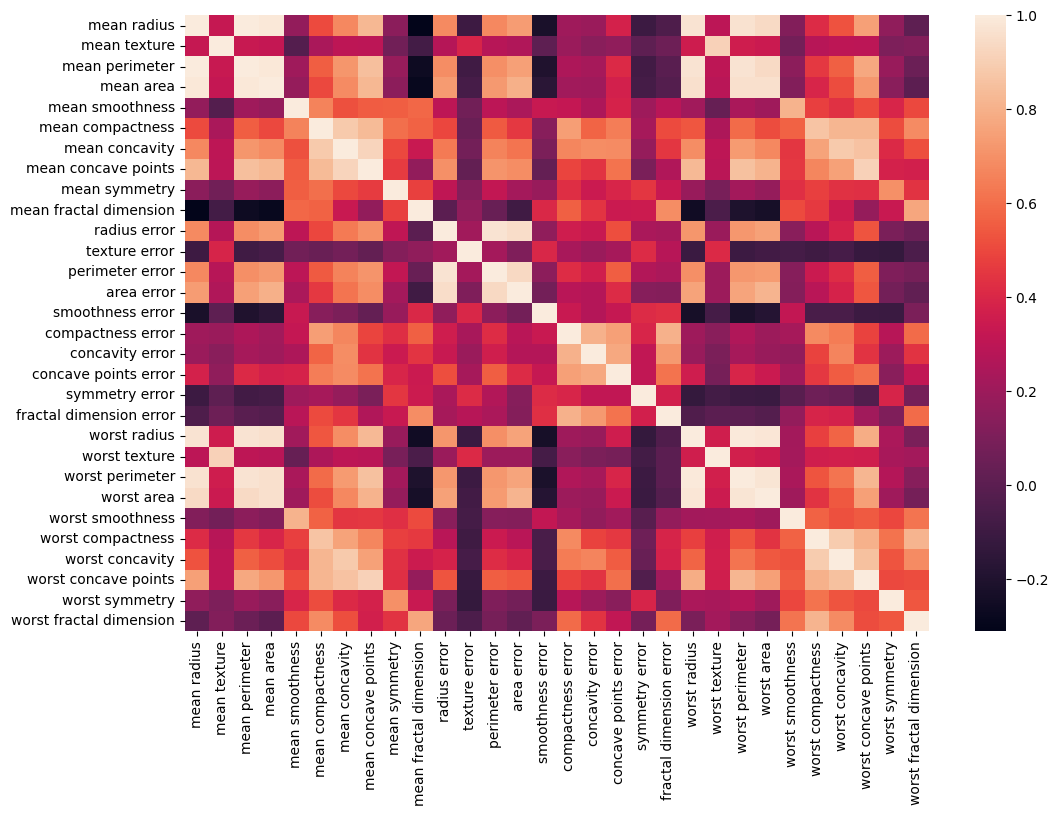

In [6]:
# corelation feature selection
correlation = x.corr()

plt.figure(figsize = (12,8))
sns.heatmap(correlation)
plt.show()

In [10]:
# select correlated features
threshold = 0.8
corr_matrix = x.corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

drop_features = [
    column
    for column in upper.columns
    if any( upper [column] > threshold)
]

x_selected = x.drop (columns = drop_features)
x_selected.shape

(569, 13)

In [16]:
#Chi Square feature selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

selector = SelectKBest(score_func = chi2 , k=10)

x_new = selector.fit_transform( x , y)

selected_features = x.columns[ selector.get_support()] # array([ True, False,  True, False,  True, ... ])

selected_features

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'perimeter error', 'area error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area'],
      dtype='object')

In [21]:
# Mutual InformatioN
 #MI = 0 → feature and target are independent → useless.
 #MI > 0 → feature carries information about the target → useful.

from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(x,y)
mi_scores = pd.DataFrame({
    "Feature": x.columns , "Score": mi
})

mi_scores.sort_values(
    by = "Score",
    ascending = False
)

,Feature,Score
22,worst perimeter,0.476091
23,worst area,0.462234
20,worst radius,0.455579
7,mean concave points,0.441966
27,worst concave points,0.438532
2,mean perimeter,0.401143
6,mean concavity,0.372343
0,mean radius,0.367967
3,mean area,0.358566
13,area error,0.340732
